## Ames Housing Data - Exploratory Data Analysis
# 
### Dataset Overview
# 
#### This notebook performs initial exploration and cleaning of the Ames Housing dataset.

### 1. Load Data

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [28]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [29]:
# Load data
df = pd.read_csv('../data/raw/AmesHousing.csv')
print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [30]:
# %%
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [31]:
# %%
# Summary statistics
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


#### 2. Target Variable Analysis


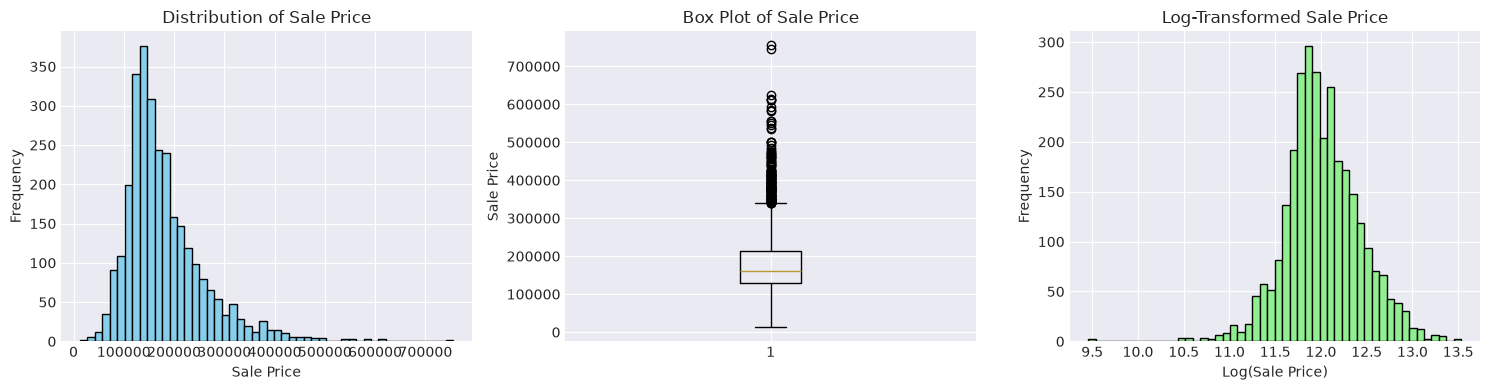

Target Statistics:
count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [32]:
# Target variable distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df['SalePrice'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Sale Price')
axes[0].set_xlabel('Sale Price')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['SalePrice'])
axes[1].set_title('Box Plot of Sale Price')
axes[1].set_ylabel('Sale Price')

# Log transformed
axes[2].hist(np.log(df['SalePrice']), bins=50, color='lightgreen', edgecolor='black')
axes[2].set_title('Log-Transformed Sale Price')
axes[2].set_xlabel('Log(Sale Price)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/figures/sale_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Target Statistics:")
print(df['SalePrice'].describe())

#### 3. Missing Values Analysis

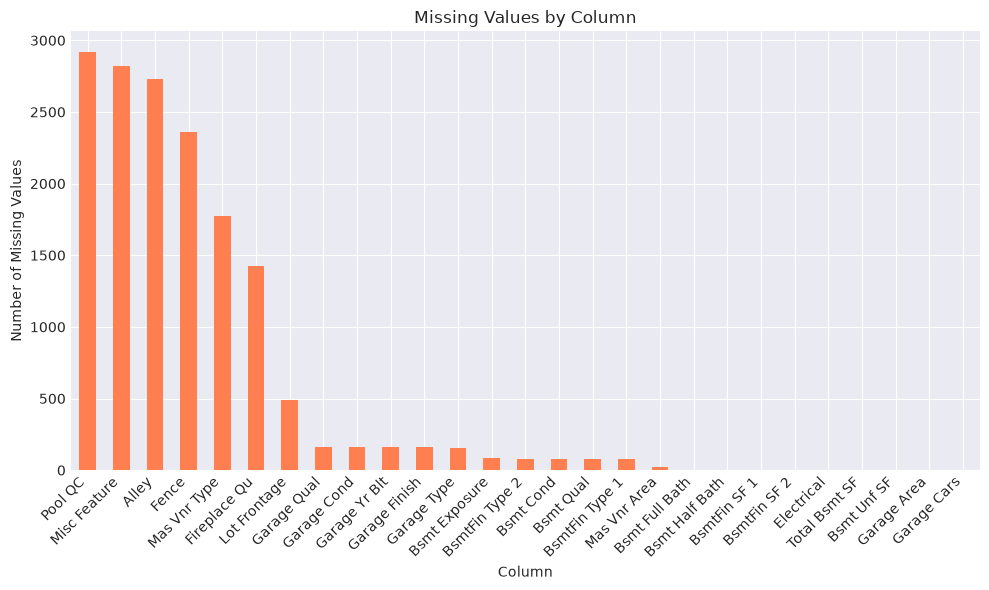

Total missing values: 15749
Columns with missing values: 27

Missing percentage by column:
Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Qual        5.426621
Garage Cond        5.426621
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Cond          2.730375
Bsmt Qual          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
BsmtFin SF 1       0.034130
BsmtFin SF 2       0.034130
Electrical         0.034130
Total Bsmt SF      0.034130
Bsmt Unf SF        0.034130
Garage Area        0.034130
Garage Cars        0.034130
dtype: float64


In [33]:
# Missing values analysis
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
missing.plot(kind='bar', color='coral')
ax.set_title('Missing Values by Column')
ax.set_xlabel('Column')
ax.set_ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Total missing values: {missing.sum()}")
print(f"Columns with missing values: {len(missing)}")
print("\nMissing percentage by column:")
print((missing / len(df) * 100).sort_values(ascending=False))

#### 4. Correlation Analysis

In [34]:
# Correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# Top correlations with SalePrice
target_corr = corr['SalePrice'].sort_values(ascending=False)
print("Top 10 Correlations with SalePrice:")
print(target_corr.head(10))

Top 10 Correlations with SalePrice:
SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Name: SalePrice, dtype: float64


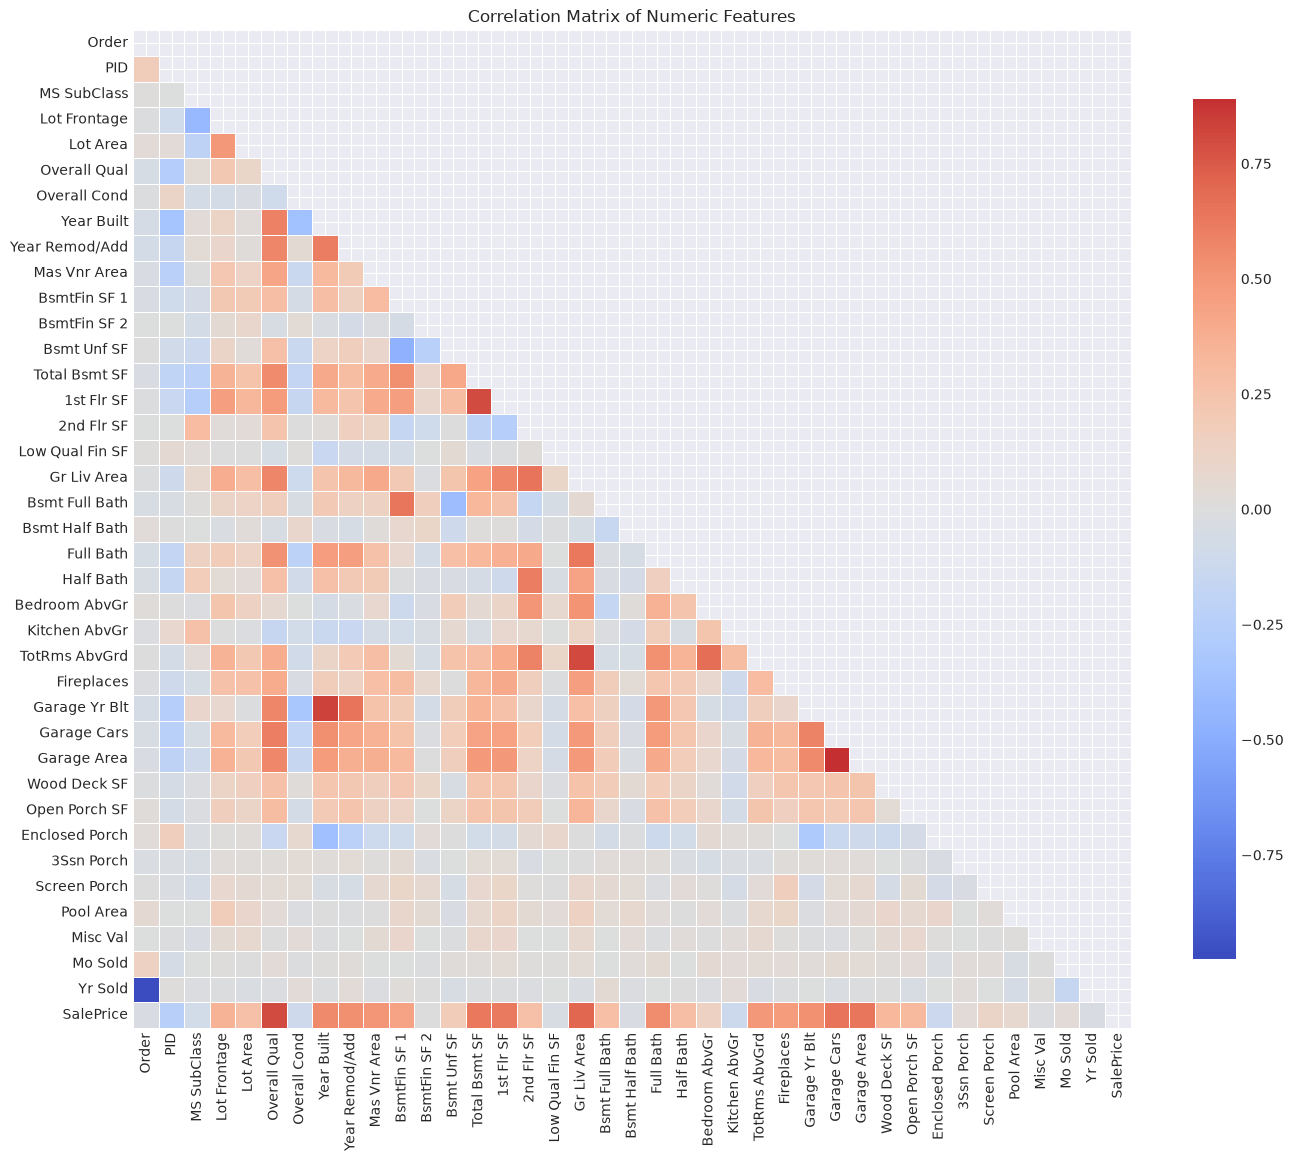

In [35]:
# Correlation heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

#### 5. Key Feature Analysis

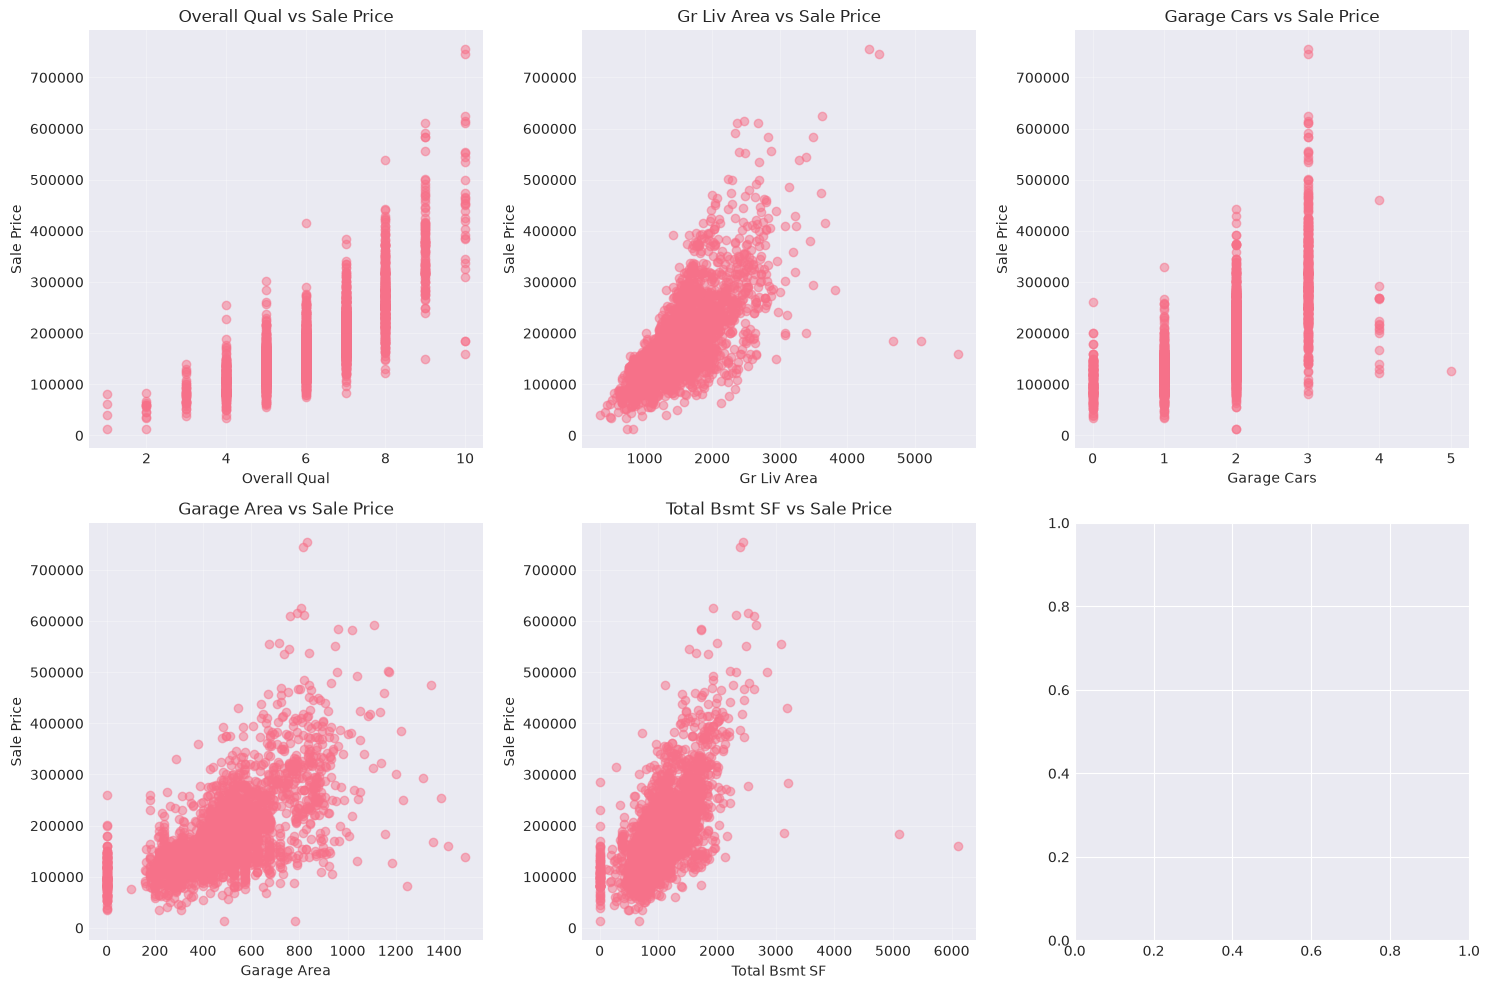

In [36]:
# Top features by correlation
top_features = target_corr.head(6).index.tolist()
top_features.remove('SalePrice')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].scatter(df[feature], df['SalePrice'], alpha=0.5)
    axes[i].set_title(f'{feature} vs Sale Price')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Sale Price')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/top_features_vs_price.png', dpi=300, bbox_inches='tight')
plt.show()

#### 6. Categorical Feature Analysis

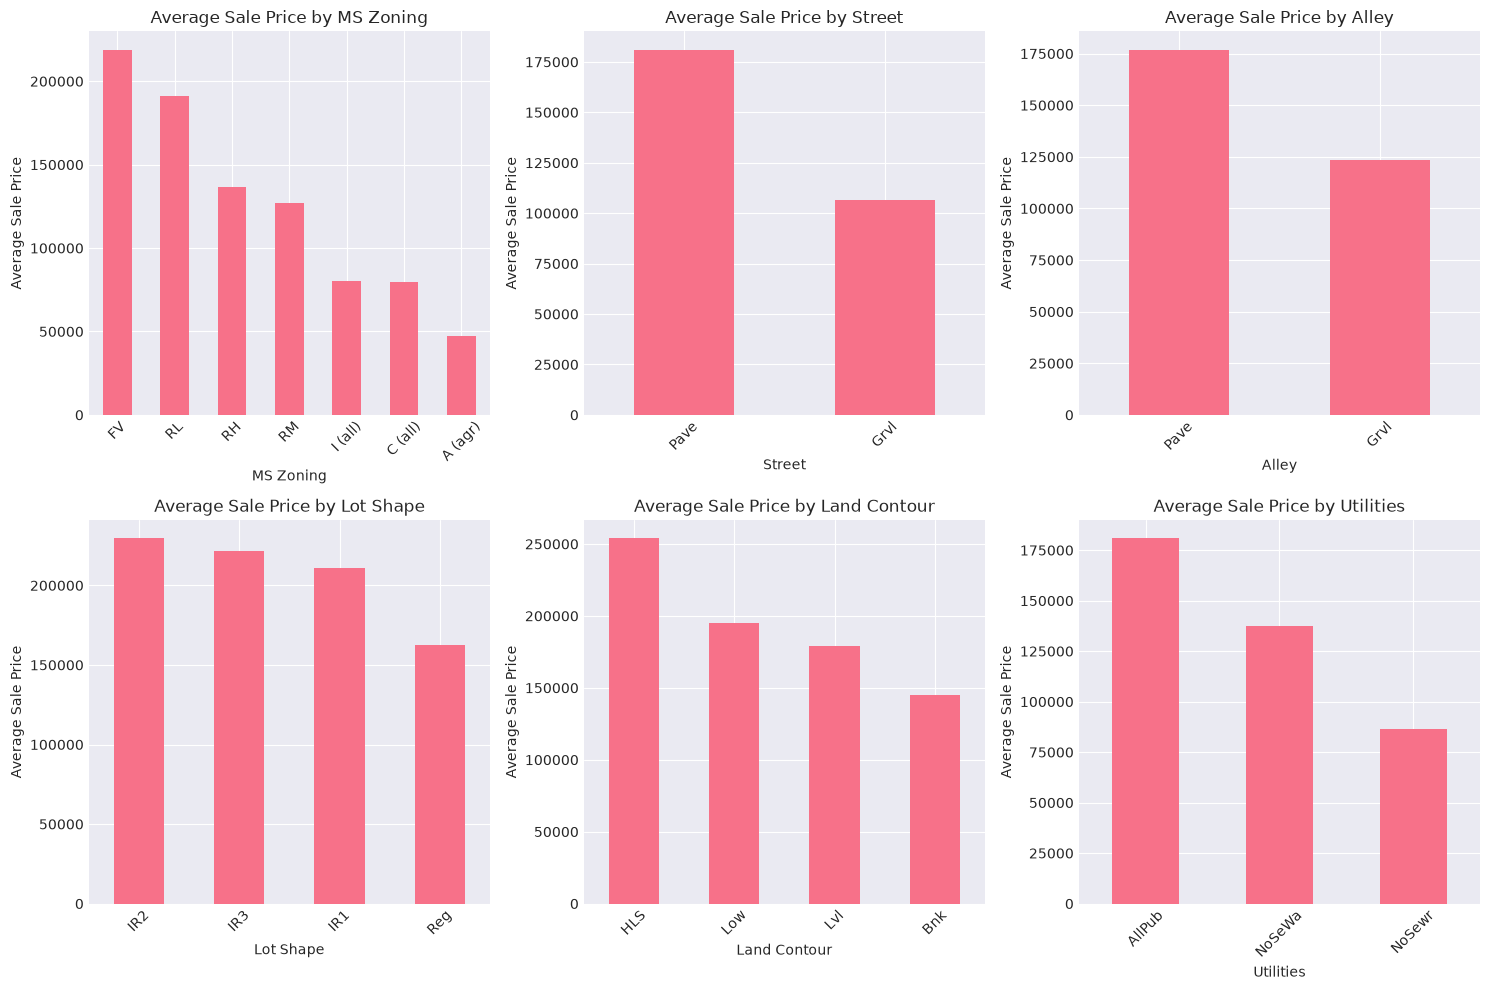

In [37]:
# Top categorical features
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if df[col].nunique() < 20]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols[:6]):
    avg_price = df.groupby(col)['SalePrice'].mean().sort_values(ascending=False)
    avg_price.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Average Sale Price by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Average Sale Price')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/categorical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

#### 7. Outlier Detection

In [38]:
# Check for outliers in key features
def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return len(outliers), len(outliers) / len(data) * 100

key_features = ['SalePrice', 'Lot Area', 'Gr Liv Area', 'Total Bsmt SF', 'Garage Area']

outlier_summary = {}
for feature in key_features:
    count, pct = detect_outliers_iqr(df, feature)
    outlier_summary[feature] = {'count': count, 'percentage': pct}

outlier_df = pd.DataFrame(outlier_summary).T
outlier_df

,count,percentage
SalePrice,137.0,4.675768
Lot Area,127.0,4.334471
Gr Liv Area,75.0,2.559727
Total Bsmt SF,123.0,4.197952
Garage Area,42.0,1.433447


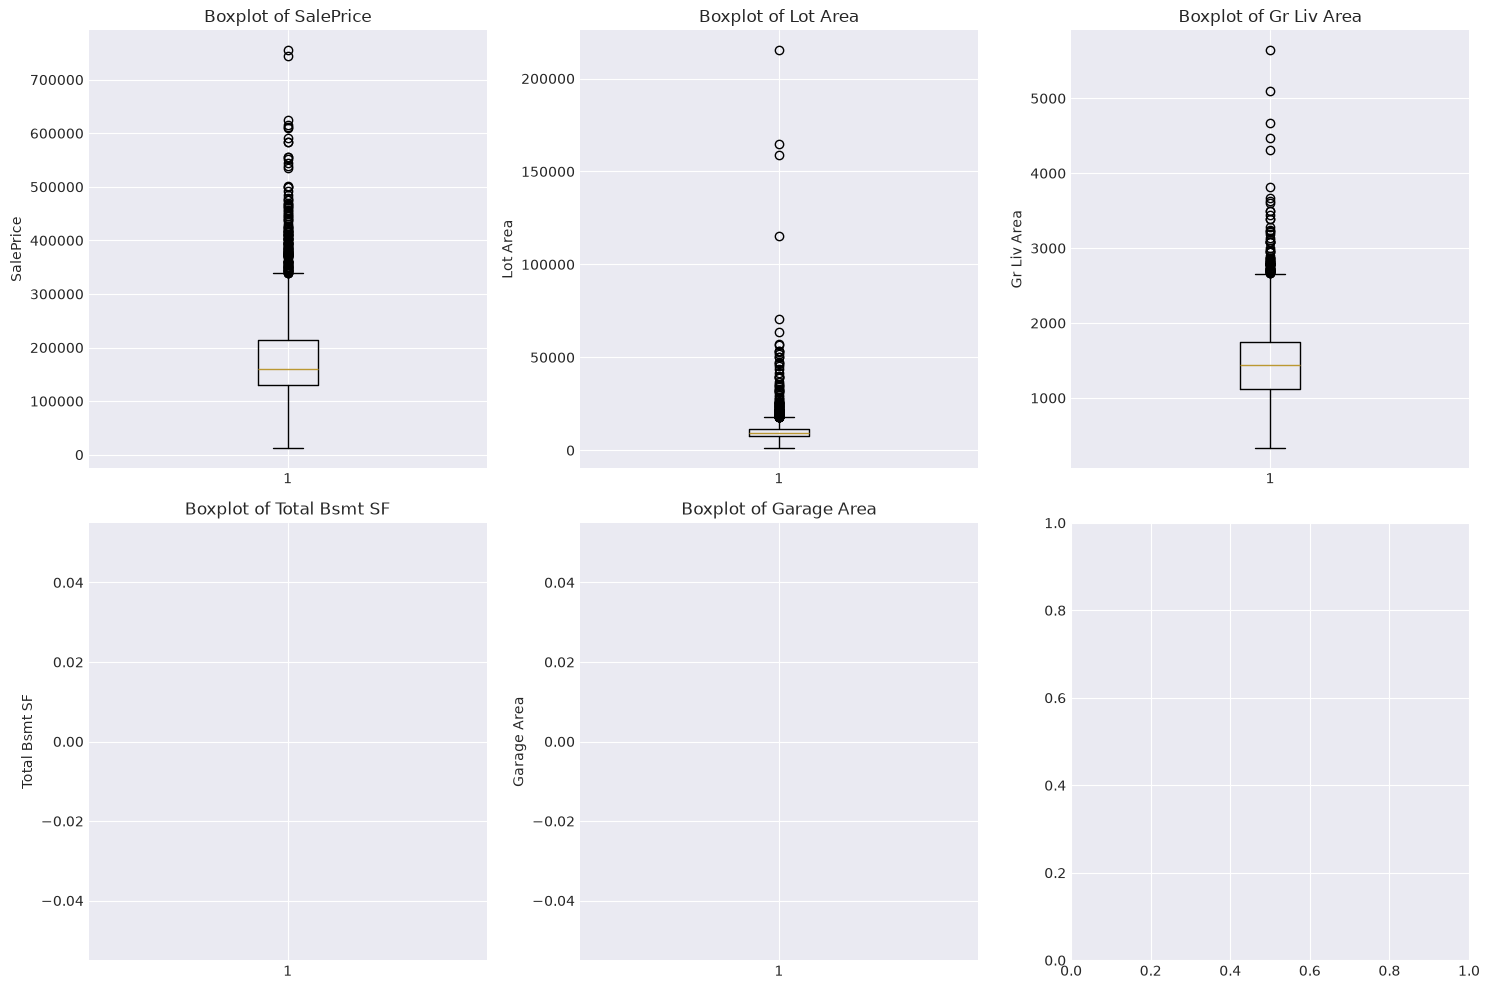

In [39]:
# Visualize outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    if i < 6:
        axes[i].boxplot(df[feature])
        axes[i].set_title(f'Boxplot of {feature}')
        axes[i].set_ylabel(feature)

plt.tight_layout()
plt.savefig('../reports/figures/outlier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()